Testing simulate_midspan_moment


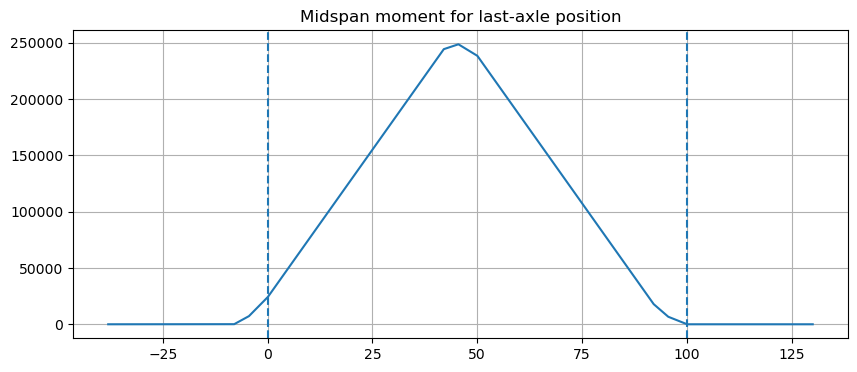

Vehicle length = 8.000 m
Position range: -38.0 m  to  130.0 m (steps = 8400)
Max midspan moment = 248737.4 kgf·m at pos_last = 45.49 m


In [9]:
import numpy as np

import matplotlib.pyplot as plt


def simulate_midspan_moment(Pi, di, l=100.0, dr=30.0, steps_per_meter=50):
    """
    this function simulates bending moment at midspan while a vehicle crosses a simply supported bridge
    
    di is distance between axles,
    dr is distance before bridge where simulation begins

    returns the following:
    pos_last is a ndarray of last axle positions, with reference to the start of the bridge
    M_mid is a ndarray of midspan moments corresponding to pos_last
    axle_pos_time is a ndarray  (len(pos_last), n) of absolute axle positions relative to bridge start
    """
    Pi = np.asarray(Pi, dtype=float)
    di = np.asarray(di, dtype=float) if len(di) > 0 else np.array([])
    n = len(Pi)
    if n == 0:
        raise ValueError("Pi must contain at least one axle load.")
    if len(di) != max(0, n-1):
        raise ValueError("di must have length n-1 where n = len(Pi).")
    
    # vehicle length (distance from front axle to last axle)
    lv = di.sum() if di.size > 0 else 0.0
    
    # compute distance from last axle to each axle (pos_from_last)
    # front-first ordering
    # pos_from_last[k] = distance from last axle to axle k
    pos_from_last = np.zeros(n)
    # For front axle (k=0) distance from last = lv
    # or more generally, pos_from_last[k] = lv - sum(di[:k])
    for k in range(n):
        if k == 0:
            pos_from_last[k] = lv
        else:
            pos_from_last[k] = lv - di[:k].sum()

    pos_from_last[-1] = 0.0
    
    # last axle position is dr + lv meters before bridge start, such that pos_last = -(dr + lv)
    # in end, last axle is dr meters past bridge end, such that pos_last = l + dr
    pos_last_start = -(dr + lv)
    pos_last_end = l + dr
    total_distance = pos_last_end - pos_last_start
    n_steps = max(3, int(np.ceil(total_distance * steps_per_meter)))
    pos_last = np.linspace(pos_last_start, pos_last_end, n_steps)
    
    M_mid = np.zeros_like(pos_last)
    axle_pos_time = np.zeros((len(pos_last), n))
    
    for i, pl in enumerate(pos_last):
        axle_pos = pl + pos_from_last  # absolute positions of each axle
        axle_pos_time[i, :] = axle_pos.copy()
        
        # identify axles that are actually on the bridge
        on_bridge_mask = (axle_pos >= 0.0) & (axle_pos <= l)
        if not on_bridge_mask.any():
            # no loads on bridge, support reactions zero, midspan moment zero
            M_mid[i] = 0.0
            continue
        
        a_i = axle_pos[on_bridge_mask]
        P_i = Pi[on_bridge_mask]
        
        # compute exact reactions for simply supported beam
        Ay = np.sum(P_i * (l - a_i) / l)
        # internal moment at midspan 
        left_mask = (axle_pos >= 0.0) & (axle_pos <= l/2.0)
        P_left = Pi[left_mask]
        a_left = axle_pos[left_mask]
        
        M_mid[i] = Ay * (l / 2.0) - np.sum(P_left * ((l / 2.0) - a_left))
    
    return pos_last, M_mid, axle_pos_time


if __name__ == "__main__":
    print("Testing simulate_midspan_moment")
    
    Pi_example = [4000.0, 3500.0, 3000.0]  # front, middle, rear axles
    di_example = [3.5, 4.5] 
    l = 100.0
    dr = 30.0
    pos_last, M_mid, axle_pos_time = simulate_midspan_moment(Pi_example, di_example, l=l, dr=dr, steps_per_meter=50)
    
    plt.figure(figsize=(10,4))
    plt.plot(pos_last, M_mid)
    plt.axvline(0, linestyle='--') 
    plt.axvline(l, linestyle='--')  
    plt.title('Midspan moment for last-axle position')
    plt.grid(True)
    plt.show()

    print(f"Vehicle length = {sum(di_example):.3f} m")
    print(f"Position range: {pos_last[0]:.1f} m  to  {pos_last[-1]:.1f} m (steps = {len(pos_last)})")
    print(f"Max midspan moment = {M_mid.max():.1f} kgf·m at pos_last = {pos_last[M_mid.argmax()]:.2f} m")
